# Deep Learning Time Series Forecasting (PyTorch Edition)
## Electricity Consumption Forecasting - Improved Version

**Improvements Applied:**
- Log-transform target to handle skewed distribution
- Asymmetric loss function to capture peaks
- Lag features and rolling statistics
- Peak-aware evaluation metrics

In [1]:
import pandas as pd
df=pd.read_csv("household_power_consumption.csv")
df.info()

C:\Users\Sriramakrishnan\AppData\Local\Temp\ipykernel_15900\1645837817.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("household_power_consumption.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## Phase 1-3: Data Loading, Cleaning, Aggregation

In [3]:
DATA_PATH = r"household_power_consumption.csv"

def load_and_clean_data(filepath):
    df = pd.read_csv(filepath, na_values=['?'], low_memory=False)
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    df = df.set_index('datetime').drop(['Date', 'Time'], axis=1)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit=5).ffill().bfill()
    df = df.resample('h').mean()
    return df

df_hourly = load_and_clean_data(DATA_PATH)
print(f"Dataset shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")

Dataset shape: (34589, 7)
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


---
## Phase 4: EDA (Key Visualizations)

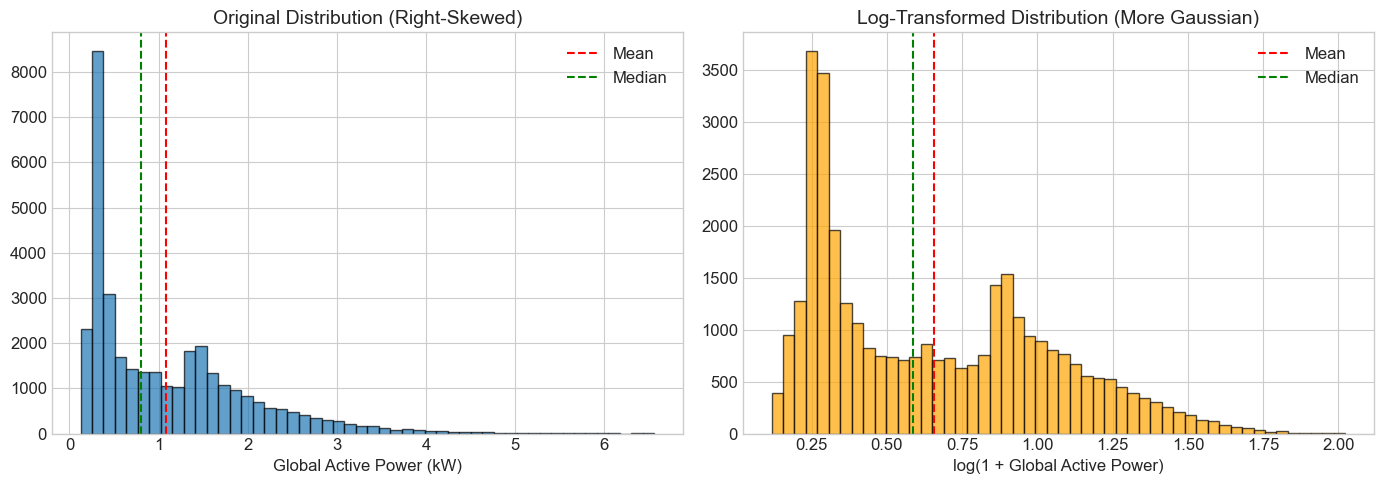

Original skewness: 1.31
Log-transformed skewness: 0.56


In [4]:
# Distribution Analysis - Before and After Log Transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_hourly['Global_active_power'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Distribution (Right-Skewed)', fontsize=14)
axes[0].set_xlabel('Global Active Power (kW)')
axes[0].axvline(df_hourly['Global_active_power'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df_hourly['Global_active_power'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

log_power = np.log1p(df_hourly['Global_active_power'])
axes[1].hist(log_power, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log-Transformed Distribution (More Gaussian)', fontsize=14)
axes[1].set_xlabel('log(1 + Global Active Power)')
axes[1].axvline(log_power.mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(log_power.median(), color='green', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Original skewness: {df_hourly['Global_active_power'].skew():.2f}")
print(f"Log-transformed skewness: {log_power.skew():.2f}")

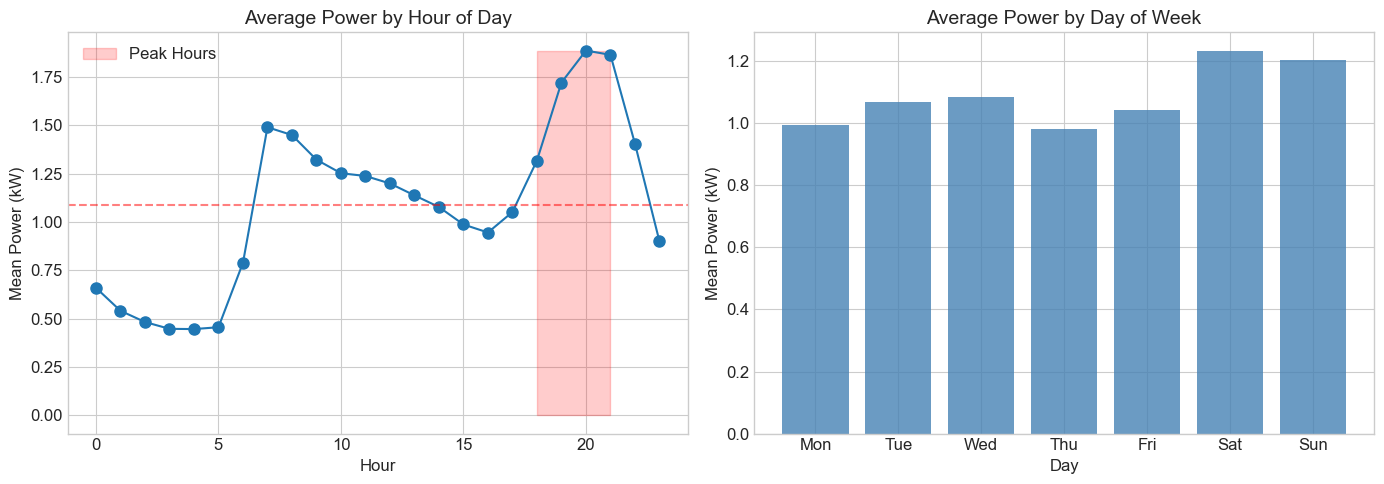

In [5]:
# Seasonal Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_pattern = df_hourly.groupby(df_hourly.index.hour)['Global_active_power'].mean()
axes[0].plot(hourly_pattern.index, hourly_pattern.values, 'o-', markersize=8)
axes[0].set_title('Average Power by Hour of Day', fontsize=14)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Power (kW)')
axes[0].axhline(hourly_pattern.mean(), color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(range(18, 22), 0, hourly_pattern.max(), alpha=0.2, color='red', label='Peak Hours')
axes[0].legend()

weekly_pattern = df_hourly.groupby(df_hourly.index.dayofweek)['Global_active_power'].mean()
axes[1].bar(range(7), weekly_pattern.values, color='steelblue', alpha=0.8)
axes[1].set_title('Average Power by Day of Week', fontsize=14)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Power (kW)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

---
## Phase 5: Feature Engineering (IMPROVED)

In [6]:
def add_features(df):
    df = df.copy()
    
    # Cyclical time features
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    
    # Peak hour indicator
    df['is_peak_hour'] = ((df.index.hour >= 18) & (df.index.hour <= 21)).astype(float)
    
    # Lag features
    df['power_lag_1h'] = df['Global_active_power'].shift(1)
    df['power_lag_24h'] = df['Global_active_power'].shift(24)
    df['power_lag_168h'] = df['Global_active_power'].shift(168)
    
    # Rolling statistics
    df['power_rolling_mean_24h'] = df['Global_active_power'].rolling(24, min_periods=1).mean()
    df['power_rolling_std_24h'] = df['Global_active_power'].rolling(24, min_periods=1).std()
    df['power_rolling_max_24h'] = df['Global_active_power'].rolling(24, min_periods=1).max()
    
    return df.dropna()

df_features = add_features(df_hourly)
print(f"Shape after feature engineering: {df_features.shape}")

Shape after feature engineering: (34421, 20)


In [7]:
# Apply LOG TRANSFORM to target
df_features['Global_active_power_log'] = np.log1p(df_features['Global_active_power'])

# Log-transform lag features
for col in ['power_lag_1h', 'power_lag_24h', 'power_lag_168h', 
            'power_rolling_mean_24h', 'power_rolling_max_24h']:
    df_features[f'{col}_log'] = np.log1p(df_features[col])

print("Log-transformed target and lag features.")

Log-transformed target and lag features.


---
## Phase 6: Sliding Window Dataset

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_width, label_width, shift, target_col_idx=0):
        self.data = torch.tensor(data.values, dtype=torch.float32)
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift
        self.target_col_idx = target_col_idx
        self.num_samples = max(0, len(self.data) - self.total_window_size + 1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        window = self.data[idx : idx + self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, self.target_col_idx]
        return inputs, labels

In [9]:
# Feature columns
feature_columns = [
    'Global_active_power_log',
    'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_peak_hour',
    'power_lag_1h_log', 'power_lag_24h_log', 'power_lag_168h_log',
    'power_rolling_mean_24h_log', 'power_rolling_std_24h', 'power_rolling_max_24h_log'
]
feature_columns = [c for c in feature_columns if c in df_features.columns]
df_model = df_features[feature_columns].copy()
N_FEATURES = len(feature_columns)

# Split
n = len(df_model)
train_df = df_model[:int(n * 0.7)]
val_df = df_model[int(n * 0.7):int(n * 0.85)]
test_df = df_model[int(n * 0.85):]

# Scale
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df), columns=val_df.columns, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Features: {N_FEATURES}")

Train: 24094, Val: 5163, Test: 5164
Features: 20


In [10]:
INPUT_WIDTH = 168
LABEL_WIDTH = 24
BATCH_SIZE = 64

train_ds = TimeSeriesDataset(train_scaled, INPUT_WIDTH, LABEL_WIDTH, LABEL_WIDTH, target_col_idx=0)
val_ds = TimeSeriesDataset(val_scaled, INPUT_WIDTH, LABEL_WIDTH, LABEL_WIDTH, target_col_idx=0)
test_ds = TimeSeriesDataset(test_scaled, INPUT_WIDTH, LABEL_WIDTH, LABEL_WIDTH, target_col_idx=0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

for inputs, labels in train_loader:
    print(f"Inputs: {inputs.shape}, Labels: {labels.shape}")
    break

Inputs: torch.Size([64, 168, 20]), Labels: torch.Size([64, 24])


---
## Phase 7-8: Model Architectures

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_steps, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_steps)
        )
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_steps, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.attention = nn.MultiheadAttention(hidden_size * 2, num_heads=4, 
                                                dropout=dropout, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_steps)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        context = attn_out.mean(dim=1)
        return self.fc(context)

print("Models defined.")

Models defined.


---
## Phase 9: Loss Functions & Training

In [12]:
class AsymmetricMSELoss(nn.Module):
    """Penalizes under-prediction more than over-prediction."""
    def __init__(self, alpha=2.0):
        super().__init__()
        self.alpha = alpha
    
    def forward(self, pred, target):
        error = target - pred
        loss = torch.where(
            error > 0,
            self.alpha * error ** 2,
            error ** 2
        )
        return loss.mean()

print("AsymmetricMSELoss defined.")

AsymmetricMSELoss defined.


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, criterion, epochs=30, lr=0.001, patience=7):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                            factor=0.5, patience=3)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.6f}, Val: {val_loss:.6f}, LR: {current_lr:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    if best_state:
        model.load_state_dict(best_state)
    return train_losses, val_losses

print("Training functions defined.")

Training functions defined.


In [14]:
# Train LSTM
print("=" * 60)
print("Training Improved LSTM with Asymmetric Loss...")
print("=" * 60)

lstm_model = LSTMModel(N_FEATURES, hidden_size=128, output_steps=LABEL_WIDTH, 
                       num_layers=2, dropout=0.3).to(device)
asymmetric_loss = AsymmetricMSELoss(alpha=2.0)

lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader, 
    criterion=asymmetric_loss, epochs=40, lr=0.001, patience=7
)

Training Improved LSTM with Asymmetric Loss...
Epoch 1/40 - Train: 0.958922, Val: 0.738326, LR: 0.001000
Epoch 2/40 - Train: 0.747326, Val: 0.770901, LR: 0.001000
Epoch 3/40 - Train: 0.657467, Val: 0.826921, LR: 0.001000
Epoch 4/40 - Train: 0.581139, Val: 0.823196, LR: 0.001000
Epoch 5/40 - Train: 0.523840, Val: 0.842958, LR: 0.001000
Epoch 6/40 - Train: 0.479596, Val: 0.861946, LR: 0.000500
Epoch 7/40 - Train: 0.462797, Val: 0.857648, LR: 0.000500
Epoch 8/40 - Train: 0.449410, Val: 0.874275, LR: 0.000500
Early stopping at epoch 8


In [15]:
# Train Attention LSTM
print("=" * 60)
print("Training Attention LSTM with Asymmetric Loss...")
print("=" * 60)

attn_model = AttentionLSTM(N_FEATURES, hidden_size=64, output_steps=LABEL_WIDTH,
                           num_layers=2, dropout=0.3).to(device)

attn_train_losses, attn_val_losses = train_model(
    attn_model, train_loader, val_loader,
    criterion=asymmetric_loss, epochs=40, lr=0.001, patience=7
)

Training Attention LSTM with Asymmetric Loss...
Epoch 1/40 - Train: 1.284233, Val: 1.230783, LR: 0.001000
Epoch 2/40 - Train: 1.193281, Val: 0.943578, LR: 0.001000
Epoch 3/40 - Train: 0.808056, Val: 0.730541, LR: 0.001000
Epoch 4/40 - Train: 0.701023, Val: 0.770235, LR: 0.001000
Epoch 5/40 - Train: 0.638864, Val: 0.797351, LR: 0.001000
Epoch 6/40 - Train: 0.593394, Val: 0.829035, LR: 0.001000
Epoch 7/40 - Train: 0.563151, Val: 0.813746, LR: 0.001000
Epoch 8/40 - Train: 0.522529, Val: 0.840910, LR: 0.000500
Epoch 9/40 - Train: 0.508027, Val: 0.849806, LR: 0.000500
Epoch 10/40 - Train: 0.498290, Val: 0.863811, LR: 0.000500
Early stopping at epoch 10


---
## Phase 10: Evaluation

In [16]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def inverse_transform_log(preds, labels, scaler, target_idx=0):
    mean, std = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds_log = preds * std + mean
    labels_log = labels * std + mean
    preds_orig = np.expm1(preds_log)
    labels_orig = np.expm1(labels_log)
    return preds_orig, labels_orig


def calculate_metrics(preds, labels, peak_threshold=2.0):
    rmse = np.sqrt(np.mean((preds - labels) ** 2))
    mae = np.mean(np.abs(preds - labels))
    mape = np.mean(np.abs((labels - preds) / (np.abs(labels) + 1e-8))) * 100
    
    peak_mask = labels > peak_threshold
    if peak_mask.sum() > 0:
        peak_rmse = np.sqrt(np.mean((preds[peak_mask] - labels[peak_mask]) ** 2))
        peak_mae = np.mean(np.abs(preds[peak_mask] - labels[peak_mask]))
        peak_mape = np.mean(np.abs((labels[peak_mask] - preds[peak_mask]) / labels[peak_mask])) * 100
    else:
        peak_rmse = peak_mae = peak_mape = np.nan
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape,
            'Peak_RMSE': peak_rmse, 'Peak_MAE': peak_mae, 'Peak_MAPE': peak_mape}

In [17]:
# Evaluate
print("\n" + "=" * 60)
print("EVALUATION METRICS")
print("=" * 60)

lstm_preds_scaled, lstm_labels_scaled = get_predictions(lstm_model, test_loader, device)
lstm_preds, lstm_labels = inverse_transform_log(lstm_preds_scaled, lstm_labels_scaled, scaler)
lstm_metrics = calculate_metrics(lstm_preds, lstm_labels)
print(f"\nLSTM: RMSE={lstm_metrics['RMSE']:.4f}, MAE={lstm_metrics['MAE']:.4f}, Peak_MAE={lstm_metrics['Peak_MAE']:.4f}")

attn_preds_scaled, attn_labels_scaled = get_predictions(attn_model, test_loader, device)
attn_preds, attn_labels = inverse_transform_log(attn_preds_scaled, attn_labels_scaled, scaler)
attn_metrics = calculate_metrics(attn_preds, attn_labels)
print(f"Attention: RMSE={attn_metrics['RMSE']:.4f}, MAE={attn_metrics['MAE']:.4f}, Peak_MAE={attn_metrics['Peak_MAE']:.4f}")


EVALUATION METRICS

LSTM: RMSE=0.5874, MAE=0.4508, Peak_MAE=0.9966
Attention: RMSE=0.5988, MAE=0.4436, Peak_MAE=1.0765


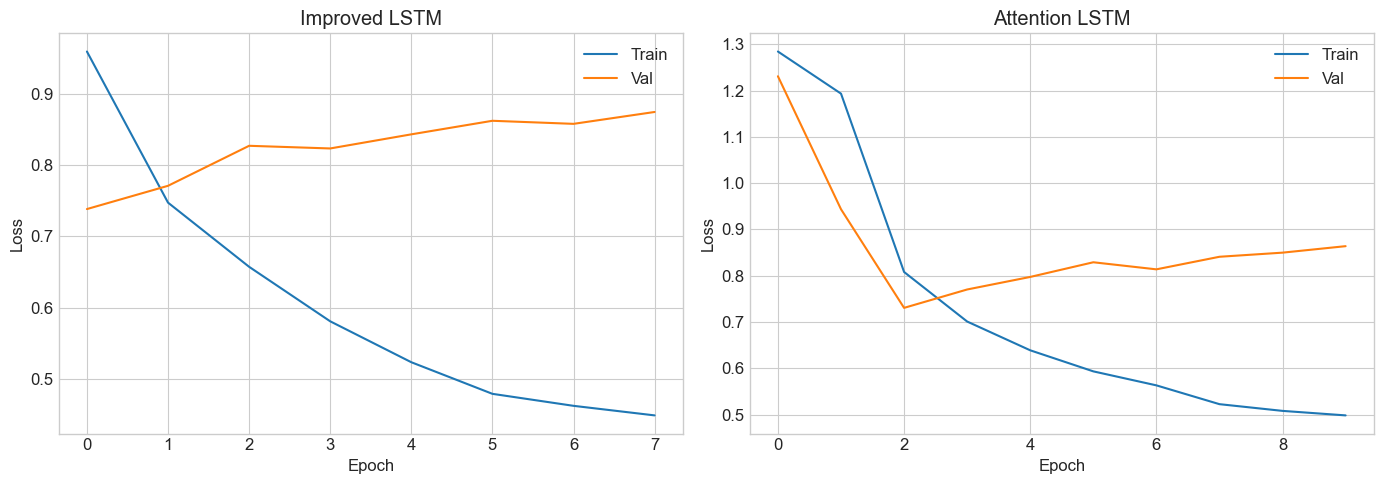

In [18]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_train_losses, label='Train')
axes[0].plot(lstm_val_losses, label='Val')
axes[0].set_title('Improved LSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(attn_train_losses, label='Train')
axes[1].plot(attn_val_losses, label='Val')
axes[1].set_title('Attention LSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Found 3222 test samples with peaks > 2.0 kW


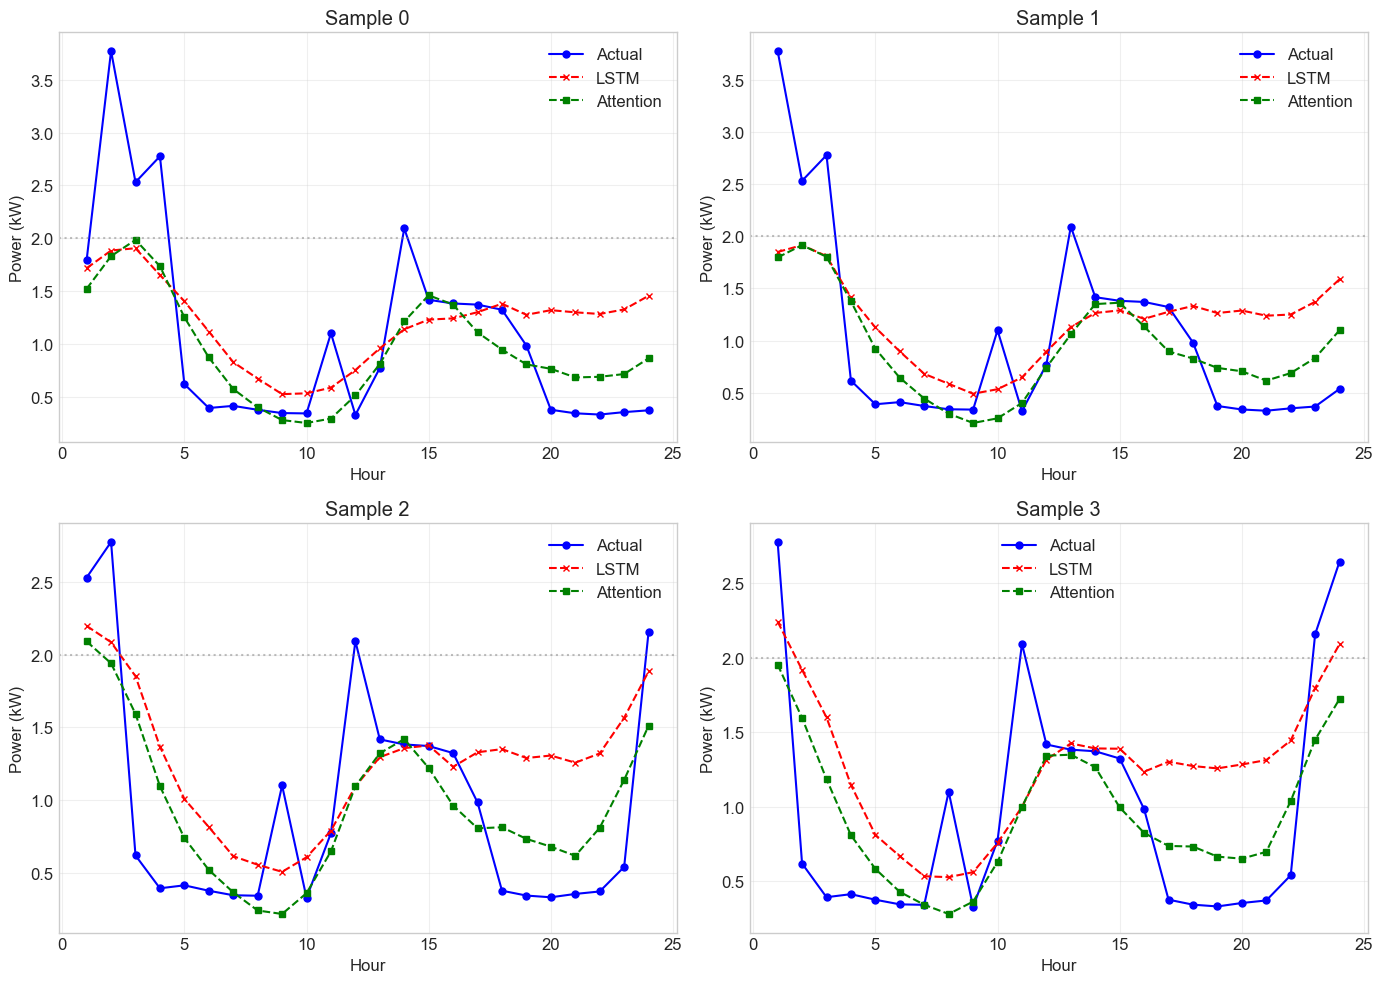

In [19]:
# Find peak samples
peak_samples = np.where(lstm_labels.max(axis=1) > 2.0)[0]
print(f"Found {len(peak_samples)} test samples with peaks > 2.0 kW")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
hours = range(1, LABEL_WIDTH + 1)

for i, sample_idx in enumerate(peak_samples[:4]):
    ax = axes[i // 2, i % 2]
    ax.plot(hours, lstm_labels[sample_idx], 'b-o', label='Actual', markersize=5)
    ax.plot(hours, lstm_preds[sample_idx], 'r--x', label='LSTM', markersize=5)
    ax.plot(hours, attn_preds[sample_idx], 'g--s', label='Attention', markersize=5)
    ax.axhline(2.0, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'Sample {sample_idx}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Power (kW)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Model Comparison
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)', 'Peak RMSE', 'Peak MAE', 'Peak MAPE (%)'],
    'LSTM': [f"{lstm_metrics['RMSE']:.4f}", f"{lstm_metrics['MAE']:.4f}", 
             f"{lstm_metrics['MAPE']:.2f}", f"{lstm_metrics['Peak_RMSE']:.4f}",
             f"{lstm_metrics['Peak_MAE']:.4f}", f"{lstm_metrics['Peak_MAPE']:.2f}"],
    'Attention': [f"{attn_metrics['RMSE']:.4f}", f"{attn_metrics['MAE']:.4f}",
                  f"{attn_metrics['MAPE']:.2f}", f"{attn_metrics['Peak_RMSE']:.4f}",
                  f"{attn_metrics['Peak_MAE']:.4f}", f"{attn_metrics['Peak_MAPE']:.2f}"]
})
print(comparison.to_string(index=False))


MODEL COMPARISON
       Metric   LSTM Attention
         RMSE 0.5874    0.5988
          MAE 0.4508    0.4436
     MAPE (%)  77.04     69.96
    Peak RMSE 1.1582    1.2426
     Peak MAE 0.9966    1.0765
Peak MAPE (%)  37.90     41.17


# Improved Deep Learning for Energy Consumption Forecasting (Phase 2 & 3)

This notebook implements a standardized, robust pipeline for forecasting household electric power consumption using a hybrid CNN-LSTM architecture.

### Key Improvements:
- **Framework Parity**: Standardized architecture (Hybrid CNN + 2-layer LSTM).
- **Advanced Engineering**: Cyclical time encoding (Hour/Month) and interaction features (Power Interact).
- **Training Robustness**: Early Stopping, Learning Rate Schedulers, and Gradient Clipping.
- **Accurate Evaluation**: Results and metrics (RMSE, MAE) are calculated in original units (kW) using inverse scaling.
- **Portability**: Relative path handling for dataset independence.

In [21]:
# --- Imports & Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import time
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Global Params
DATA_PATH = "household_power_consumption.csv" 
SEQ_LENGTH = 24  # 24 hours of history
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 50
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.5
PATIENCE = 10

Using device: cpu


In [22]:
# --- Advanced Data Engineering ---
def load_and_clean_data_improved(filepath):
    print("Loading and cleaning data...")
    try:
        df = pd.read_csv(filepath, sep=';', na_values=['?'], low_memory=False, 
                         infer_datetime_format=True, parse_dates={'datetime': [0, 1]}, index_col='datetime')
    except Exception:
        df = pd.read_csv(filepath, na_values=['?'], low_memory=False)
        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
        df = df.set_index('datetime').drop(['Date', 'Time'], axis=1)
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].interpolate(method='linear', limit=5).ffill().bfill()
        
    df = df.resample('h').mean()
    
    # 1. Cyclical Encoding
    df['Hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['Hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['Month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    
    # 2. Interaction Feature (Voltage * Intensity ≈ Power)
    df['Power_Interact'] = df['Voltage'] * df['Global_intensity']
    
    print(f"Data Ready. Shape: {df.shape}")
    return df

df_full = load_and_clean_data_improved(DATA_PATH)

Loading and cleaning data...
Data Ready. Shape: (34589, 12)


In [23]:
# --- Data Preparation ---
train_size = int(len(df_full) * 0.8)
train_df = df_full.iloc[:train_size]
test_df = df_full.iloc[train_size:]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
test_scaled = scaler.transform(test_df)

target_idx = df_full.columns.get_loc('Global_active_power')
print(f"Target column 'Global_active_power' is at index: {target_idx}")

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length, target_idx):
        self.data = torch.FloatTensor(data)
        self.seq_length = seq_length
        self.target_idx = target_idx
    def __len__(self):
        return len(self.data) - self.seq_length
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + self.seq_length, self.target_idx]
        return x, y

train_loader = DataLoader(TimeSeriesDataset(train_scaled, SEQ_LENGTH, target_idx), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(test_scaled, SEQ_LENGTH, target_idx), batch_size=BATCH_SIZE, shuffle=False)

Target column 'Global_active_power' is at index: 0


In [24]:
# --- CNN-LSTM Model Architecture ---
class CNNLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, cnn_filters=64, kernel_size=3, dropout=0.5):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Conv1d(in_channels=input_dim, out_channels=cnn_filters, kernel_size=kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(cnn_filters, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # (batch, seq, feat) -> (batch, feat, seq)
        x = x.permute(0, 2, 1) 
        out = self.cnn(x)
        out = self.relu(out)
        # (batch, feat, seq) -> (batch, seq, feat)
        out = out.permute(0, 2, 1) 
        out, _ = self.lstm(out)
        out = out[:, -1, :] # Last time step
        out = self.dropout(out)
        return self.fc(out)

In [25]:
# --- Training Logic ---
class EarlyStopping:
    def __init__(self, patience=10, path='best_model.pth'):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0

model = CNNLSTM(df_full.shape[1], 128, dropout=DROPOUT_RATE).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()
early_stop = EarlyStopping(patience=PATIENCE)

print("Starting Training...")
history = {'train': [], 'val': []}
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            val_loss += criterion(model(x), y).item()
    
    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    history['train'].append(train_loss)
    history['val'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    scheduler.step(val_loss)
    early_stop(val_loss, model)
    if early_stop.early_stop:
        print("Early stopping. Restoring best weights.")
        model.load_state_dict(torch.load('best_model.pth'))
        break

Starting Training...
Epoch 1/50 | Train: 0.4494 | Val: 0.2716 | LR: 0.001000
Epoch 2/50 | Train: 0.3740 | Val: 0.2705 | LR: 0.001000
Epoch 3/50 | Train: 0.3581 | Val: 0.2625 | LR: 0.001000
Epoch 4/50 | Train: 0.3480 | Val: 0.2633 | LR: 0.001000
Epoch 5/50 | Train: 0.3439 | Val: 0.2507 | LR: 0.001000
Epoch 6/50 | Train: 0.3389 | Val: 0.2498 | LR: 0.001000
Epoch 7/50 | Train: 0.3333 | Val: 0.2572 | LR: 0.001000
Epoch 8/50 | Train: 0.3306 | Val: 0.2602 | LR: 0.001000
Epoch 9/50 | Train: 0.3264 | Val: 0.2494 | LR: 0.001000
Epoch 10/50 | Train: 0.3234 | Val: 0.2569 | LR: 0.001000
Epoch 11/50 | Train: 0.3192 | Val: 0.2576 | LR: 0.001000
Epoch 12/50 | Train: 0.3150 | Val: 0.2532 | LR: 0.001000
Epoch 13/50 | Train: 0.3104 | Val: 0.2561 | LR: 0.001000
Epoch 14/50 | Train: 0.3052 | Val: 0.2583 | LR: 0.001000
Epoch 15/50 | Train: 0.3015 | Val: 0.2621 | LR: 0.001000
Epoch 16/50 | Train: 0.2867 | Val: 0.2602 | LR: 0.000500
Epoch 17/50 | Train: 0.2811 | Val: 0.2604 | LR: 0.000500
Epoch 18/50 | Train


FINAL METRICS (kW):
RMSE: 0.4646
MAE:  0.3193


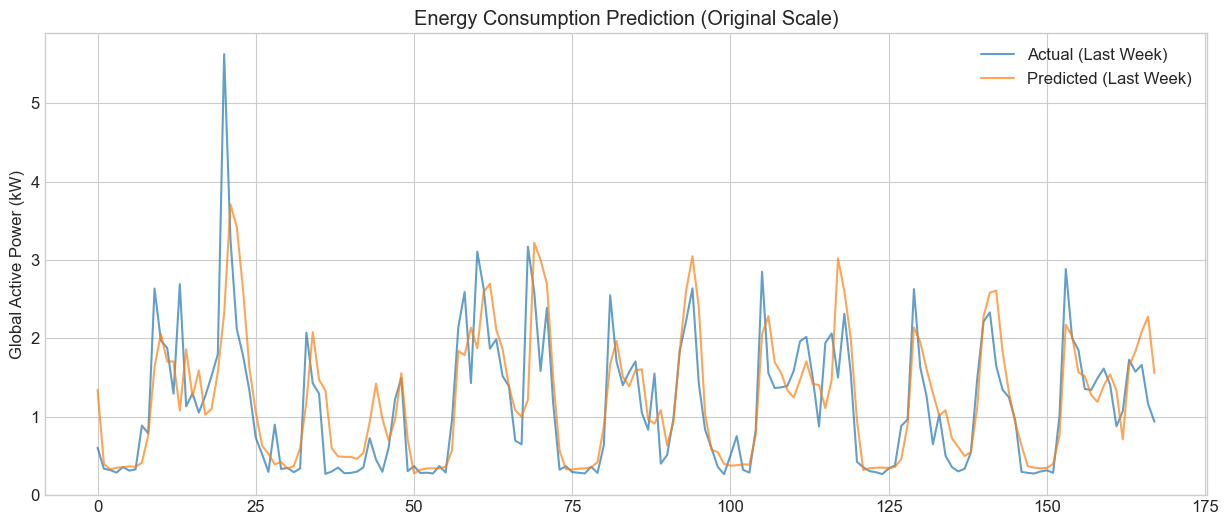

In [26]:
# --- Final Evaluation (Inverse Scaled) ---
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device)).cpu().squeeze().numpy()
        preds.extend(out)
        actuals.extend(y.numpy())

def inverse_scale_target(data, scaler, col_idx):
    dummy = np.zeros((len(data), scaler.n_features_in_))
    dummy[:, col_idx] = data
    return scaler.inverse_transform(dummy)[:, col_idx]

y_pred = inverse_scale_target(preds, scaler, target_idx)
y_true = inverse_scale_target(actuals, scaler, target_idx)

rmse = np.sqrt(np.mean((y_true - y_pred)**2))
mae = np.mean(np.abs(y_true - y_pred))

print(f"\nFINAL METRICS (kW):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

plt.figure(figsize=(15, 6))
plt.plot(y_true[-168:], label='Actual (Last Week)', alpha=0.7)
plt.plot(y_pred[-168:], label='Predicted (Last Week)', alpha=0.7)
plt.title('Energy Consumption Prediction (Original Scale)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

Found 687 test samples with peaks > 2.0 kW


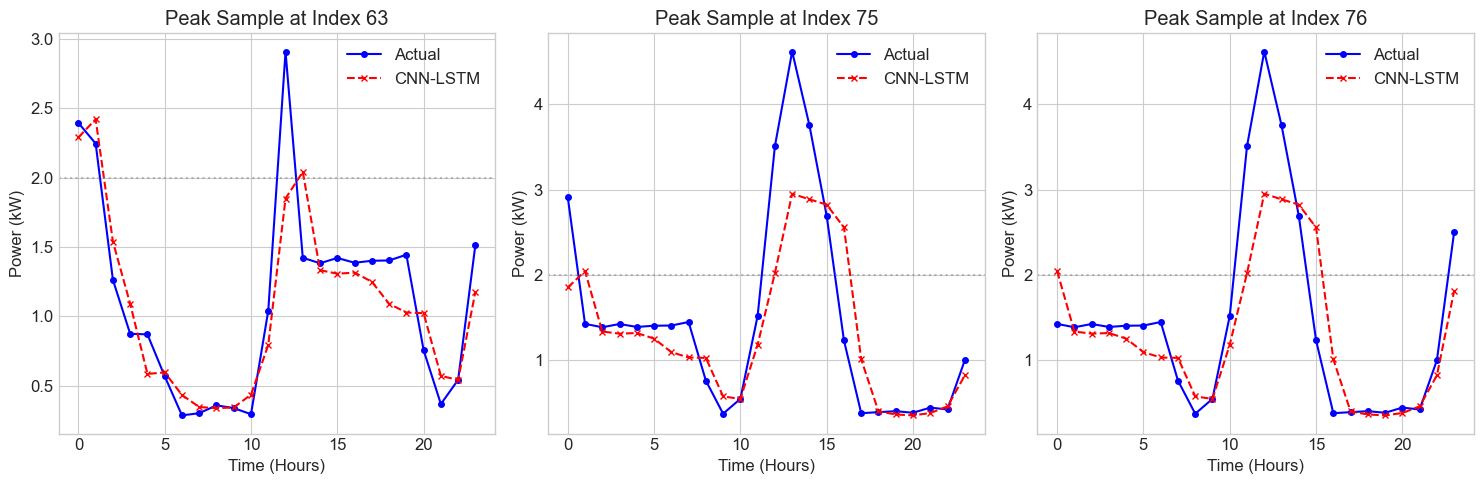

In [27]:
# --- Peak Analysis Graph ---
# Find indices where the actual value was a peak (> 2.0 kW)
peak_indices = np.where(y_true > 2.0)[0]
print(f"Found {len(peak_indices)} test samples with peaks > 2.0 kW")

# Plotting a few examples
plt.figure(figsize=(15, 5))
num_samples = min(3, len(peak_indices))

for i in range(num_samples):
    idx = peak_indices[i + 10]  # Offset slightly to see different peaks

    # Take a small window around the peak for context (e.g., 12 hours before/after)
    start, end = max(0, idx - 12), min(len(y_true), idx + 12)

    plt.subplot(1, num_samples, i + 1)
    plt.plot(y_true[start:end], 'b-o', label='Actual', markersize=4)
    plt.plot(y_pred[start:end], 'r--x', label='CNN-LSTM', markersize=4)
    plt.axhline(2.0, color='gray', linestyle=':', alpha=0.5)
    plt.title(f"Peak Sample at Index {idx}")
    plt.xlabel("Time (Hours)")
    plt.ylabel("Power (kW)")
    plt.legend()

plt.tight_layout()
plt.show()

# ⚡ Power Spike Forecasting — Transformer Models Add-On

## HOW TO USE THIS FILE
Copy all cells below and paste them **at the end** of your `energy_consumption_updated.ipynb` notebook.

These cells reuse variables that are already defined in your existing notebook:
- `train_loader`, `test_loader`, `scaler`, `target_idx`
- `AsymmetricMSELoss`, `EarlyStopping`
- `device`, `EPOCHS`, `LR`, `WEIGHT_DECAY`, `DROPOUT_RATE`, `PATIENCE`
- `SEQ_LENGTH` (= 24)
- `df_full` (used to get the feature count)
- `inverse_scale_target()` function

---
## New Models:
| # | Model | Architecture | Why it captures spikes |
|---|---|---|---|
| 4 | **TFT-Lite** | Gated Residual Network + Transformer | Variable selection weights spike-relevant features |
| 5 | **PatchTST** | Patch-tokenised input + Transformer | 4-hour patches capture local spike onset patterns |
| 6 | **CNN-Transformer** | CNN feature extractor + Transformer | CNN detects spike shapes; Transformer models global context |

In [28]:
# ============================================================
# MODEL 4 — TFT-Lite (Simplified Temporal Fusion Transformer)
# ============================================================
import math
import torch
import torch.nn as nn

class GatedResidualNetwork(nn.Module):
    """
    GRN: core building block of TFT.
    Gates (suppresses) irrelevant information so the model
    can focus on features that truly correlate with power spikes.
    """
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, hidden_dim)
        self.elu   = nn.ELU()
        self.fc2   = nn.Linear(hidden_dim, output_dim)
        self.gate  = nn.Linear(input_dim,  output_dim)
        self.sig   = nn.Sigmoid()
        self.proj  = nn.Linear(input_dim,  output_dim) if input_dim != output_dim else nn.Identity()
        self.drop  = nn.Dropout(dropout)
        self.norm  = nn.LayerNorm(output_dim)

    def forward(self, x):
        eta  = self.fc2(self.drop(self.elu(self.fc1(x))))   # non-linear transform
        gate = self.sig(self.gate(x))                        # gating signal
        out  = gate * eta + (1.0 - gate) * self.proj(x)     # skip + gate
        return self.norm(out)


class TFTLite(nn.Module):
    """
    Simplified Temporal Fusion Transformer.

    Architecture:
        Input (batch, seq_len, features)
            -> Variable Selection GRN (learns feature importance)  
            -> Linear projection to d_model
            -> Sinusoidal positional encoding
            -> TransformerEncoder (2 layers, 4 heads)
            -> Take last timestep
            -> Post-attention GRN + LayerNorm
            -> Linear -> 1
    """
    def __init__(self, input_size, d_model=128, nhead=4,
                 num_layers=2, dim_feedforward=256, dropout=0.2):
        super().__init__()
        self.d_model = d_model

        # Variable selection — learns WHICH features matter for spikes
        self.var_select = GatedResidualNetwork(input_size, d_model, d_model, dropout)
        self.input_proj  = nn.Linear(d_model, d_model)

        # Transformer encoder with batch_first=True (supported in PyTorch >= 1.9)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Post-attention GRN — refines output with skip connection
        self.post_grn = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.norm     = nn.LayerNorm(d_model)
        self.fc_out   = nn.Linear(d_model, 1)

    def _positional_encoding(self, x):
        """Sinusoidal positional encoding."""
        B, T, D = x.shape
        pe  = torch.zeros(T, D, device=x.device)
        pos = torch.arange(0, T, dtype=torch.float, device=x.device).unsqueeze(1)
        div = torch.exp(torch.arange(0, D, 2, dtype=torch.float, device=x.device)
                        * (-math.log(10000.0) / D))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:D//2])
        return x + pe.unsqueeze(0)

    def forward(self, x):              # x: (batch, seq_len, features)
        h = self.var_select(x)         # feature importance gating
        h = self.input_proj(h)         # -> (batch, seq_len, d_model)
        h = self._positional_encoding(h)
        h = self.transformer(h)        # global temporal attention
        h = h[:, -1, :]               # last timestep
        h = self.post_grn(h)           # refine with skip connection
        h = self.norm(h)
        return self.fc_out(h)          # (batch, 1)

In [29]:
# ─── Train Model 4: TFT-Lite ──────────────────────────────────────────────────
print("=" * 60)
print("Training Model 4: TFT-Lite")
print("=" * 60)

model_tft = TFTLite(
    input_size=df_full.shape[1],
    d_model=128, nhead=4, num_layers=2,
    dim_feedforward=256, dropout=0.2
).to(device)

optimizer_tft   = torch.optim.AdamW(model_tft.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_tft   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_tft, mode='min', factor=0.5, patience=5)
criterion_tft   = AsymmetricMSELoss(alpha=3.0)   # same alpha as existing models
early_stop_tft  = EarlyStopping(patience=PATIENCE, path='best_tft_lite.pth')

history_tft = {'train': [], 'val': []}

for epoch in range(EPOCHS):
    # ── Train ──
    model_tft.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer_tft.zero_grad()
        out  = model_tft(x)
        loss = criterion_tft(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model_tft.parameters(), max_norm=1.0)
        optimizer_tft.step()
        train_loss += loss.item()

    # ── Validate ──
    model_tft.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            val_loss += criterion_tft(model_tft(x), y).item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    history_tft['train'].append(train_loss)
    history_tft['val'].append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} "
          f"| LR: {optimizer_tft.param_groups[0]['lr']:.6f}")

    scheduler_tft.step(val_loss)
    early_stop_tft(val_loss, model_tft)
    if early_stop_tft.early_stop:
        print("Early stopping. Restoring best weights.")
        model_tft.load_state_dict(torch.load('best_tft_lite.pth'))
        break

Training Model 4: TFT-Lite
Epoch 1/50 | Train: 0.8496 | Val: 0.5211 | LR: 0.001000
Epoch 2/50 | Train: 0.7433 | Val: 0.5517 | LR: 0.001000
Epoch 3/50 | Train: 0.7193 | Val: 0.5190 | LR: 0.001000
Epoch 4/50 | Train: 0.7118 | Val: 0.5057 | LR: 0.001000
Epoch 5/50 | Train: 0.7033 | Val: 0.5088 | LR: 0.001000
Epoch 6/50 | Train: 0.6923 | Val: 0.5348 | LR: 0.001000
Epoch 7/50 | Train: 0.6831 | Val: 0.5359 | LR: 0.001000
Epoch 8/50 | Train: 0.6788 | Val: 0.5070 | LR: 0.001000
Epoch 9/50 | Train: 0.6733 | Val: 0.5055 | LR: 0.001000
Epoch 10/50 | Train: 0.6671 | Val: 0.5103 | LR: 0.001000
Epoch 11/50 | Train: 0.6623 | Val: 0.5453 | LR: 0.001000
Epoch 12/50 | Train: 0.6638 | Val: 0.5122 | LR: 0.001000
Epoch 13/50 | Train: 0.6672 | Val: 0.4928 | LR: 0.001000
Epoch 14/50 | Train: 0.6606 | Val: 0.5091 | LR: 0.001000
Epoch 15/50 | Train: 0.6555 | Val: 0.5117 | LR: 0.001000
Epoch 16/50 | Train: 0.6625 | Val: 0.5024 | LR: 0.001000
Epoch 17/50 | Train: 0.6640 | Val: 0.5067 | LR: 0.001000
Epoch 18/50 |


TFT-Lite METRICS (kW):
  RMSE:     0.5094
  MAE:      0.3641
  Peak_MAE: 0.5852  (on 687 spike samples)


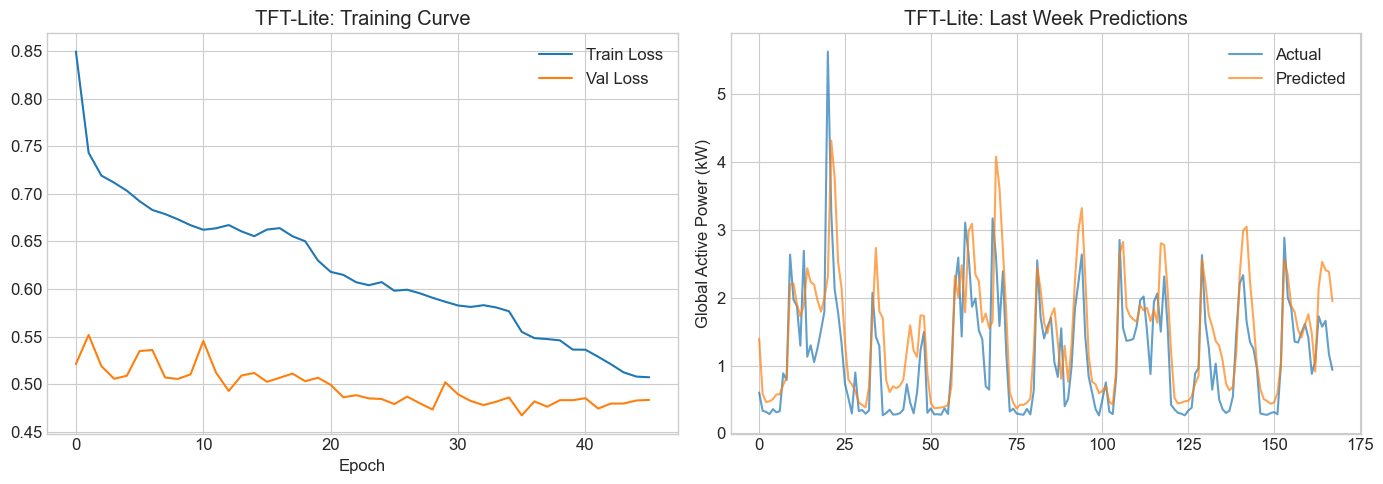

In [30]:
# ─── Evaluate Model 4: TFT-Lite ───────────────────────────────────────────────
model_tft.eval()
preds_tft, actuals_tft = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model_tft(x.to(device)).cpu().squeeze().numpy()
        preds_tft.extend(out)
        actuals_tft.extend(y.numpy())

y_pred_tft = inverse_scale_target(preds_tft,   scaler, target_idx)
y_true_tft = inverse_scale_target(actuals_tft, scaler, target_idx)

rmse_tft = np.sqrt(np.mean((y_true_tft - y_pred_tft)**2))
mae_tft  = np.mean(np.abs(y_true_tft - y_pred_tft))

# Peak MAE — samples where actual power > 2.0 kW (spike threshold)
peak_mask_tft = y_true_tft > 2.0
peak_mae_tft  = np.mean(np.abs(y_true_tft[peak_mask_tft] - y_pred_tft[peak_mask_tft]))

print(f"\nTFT-Lite METRICS (kW):")
print(f"  RMSE:     {rmse_tft:.4f}")
print(f"  MAE:      {mae_tft:.4f}")
print(f"  Peak_MAE: {peak_mae_tft:.4f}  (on {int(peak_mask_tft.sum())} spike samples)")

# ── Plot training curve + predictions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_tft['train'], label='Train Loss')
axes[0].plot(history_tft['val'],   label='Val Loss')
axes[0].set_title('TFT-Lite: Training Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(y_true_tft[-168:], label='Actual',    alpha=0.7)
axes[1].plot(y_pred_tft[-168:], label='Predicted', alpha=0.7)
axes[1].set_title('TFT-Lite: Last Week Predictions')
axes[1].set_ylabel('Global Active Power (kW)'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Model 5: PatchTST (Patch Time-Series Transformer)

**Why it helps with spikes:**
- Divides the 24-hour input into **4-hour patches** → 6 tokens for the Transformer
- Each patch = one *local context window* — the model sees the **shape of a spike onset** as a single token
- Cross-patch attention learns **when in the day** spikes typically occur
- Shorter effective sequence (6 vs 24 steps) means each attention head is more focused


In [31]:
# ============================================================
# MODEL 5 — PatchTST (Patch Time-Series Transformer)
# ============================================================

class PatchTST(nn.Module):
    """
    Patch Time-Series Transformer.

    Divides the input sequence into non-overlapping patches,
    embeds each patch as a token, then runs a Transformer encoder
    across all patch tokens.

    Architecture:
        Input (batch, seq_len, features)
            -> Reshape to (batch, n_patches, patch_size * features)
            -> Linear patch embedding          -> d_model per patch
            -> Learnable positional encoding
            -> TransformerEncoder (2 layers, 4 heads)
            -> Flatten all patch embeddings
            -> Linear -> 1
    """
    def __init__(self, input_size, seq_len=24, patch_size=4,
                 d_model=128, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.2):
        super().__init__()
        assert seq_len % patch_size == 0, (
            f"seq_len ({seq_len}) must be divisible by patch_size ({patch_size})"
        )
        self.patch_size = patch_size
        self.n_patches  = seq_len // patch_size
        patch_dim       = patch_size * input_size

        # Patch embedding: flatten raw patch -> d_model
        self.patch_embed = nn.Linear(patch_dim, d_model)

        # Learnable positional encoding (one vector per patch)
        self.pos_embed   = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Transformer encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.drop   = nn.Dropout(dropout)
        self.fc_out = nn.Linear(self.n_patches * d_model, 1)

    def forward(self, x):                   # x: (batch, seq_len, features)
        B, T, F = x.shape
        P = self.patch_size
        # Reshape into patches: (batch, n_patches, patch_size * features)
        x = x.reshape(B, T // P, P * F)
        h = self.patch_embed(x)             # (batch, n_patches, d_model)
        h = h + self.pos_embed              # add positional encoding
        h = self.drop(h)
        h = self.transformer(h)             # attention across patches
        h = h.flatten(1)                    # (batch, n_patches * d_model)
        return self.fc_out(h)               # (batch, 1)

In [32]:
# ─── Train Model 5: PatchTST ─────────────────────────────────────────────────
print("=" * 60)
print("Training Model 5: PatchTST")
print("=" * 60)

# SEQ_LENGTH=24, patch_size=4 -> 6 patches (each patch = 4 hours)
model_patch = PatchTST(
    input_size=df_full.shape[1],
    seq_len=SEQ_LENGTH,
    patch_size=4,
    d_model=128, nhead=4, num_layers=2,
    dim_feedforward=256, dropout=0.2
).to(device)

optimizer_patch   = torch.optim.AdamW(model_patch.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_patch   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_patch, mode='min', factor=0.5, patience=5)
criterion_patch   = AsymmetricMSELoss(alpha=3.0)
early_stop_patch  = EarlyStopping(patience=PATIENCE, path='best_patchtst.pth')

history_patch = {'train': [], 'val': []}

for epoch in range(EPOCHS):
    model_patch.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer_patch.zero_grad()
        out  = model_patch(x)
        loss = criterion_patch(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model_patch.parameters(), max_norm=1.0)
        optimizer_patch.step()
        train_loss += loss.item()

    model_patch.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            val_loss += criterion_patch(model_patch(x), y).item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    history_patch['train'].append(train_loss)
    history_patch['val'].append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} "
          f"| LR: {optimizer_patch.param_groups[0]['lr']:.6f}")

    scheduler_patch.step(val_loss)
    early_stop_patch(val_loss, model_patch)
    if early_stop_patch.early_stop:
        print("Early stopping. Restoring best weights.")
        model_patch.load_state_dict(torch.load('best_patchtst.pth'))
        break

Training Model 5: PatchTST
Epoch 1/50 | Train: 0.9008 | Val: 0.5818 | LR: 0.001000
Epoch 2/50 | Train: 0.8015 | Val: 0.5623 | LR: 0.001000
Epoch 3/50 | Train: 0.7594 | Val: 0.5956 | LR: 0.001000
Epoch 4/50 | Train: 0.7485 | Val: 0.6257 | LR: 0.001000
Epoch 5/50 | Train: 0.7301 | Val: 0.5804 | LR: 0.001000
Epoch 6/50 | Train: 0.7251 | Val: 0.5546 | LR: 0.001000
Epoch 7/50 | Train: 0.7195 | Val: 0.5461 | LR: 0.001000
Epoch 8/50 | Train: 0.7053 | Val: 0.5456 | LR: 0.001000
Epoch 9/50 | Train: 0.7020 | Val: 0.5664 | LR: 0.001000
Epoch 10/50 | Train: 0.6865 | Val: 0.5091 | LR: 0.001000
Epoch 11/50 | Train: 0.6887 | Val: 0.5730 | LR: 0.001000
Epoch 12/50 | Train: 0.6810 | Val: 0.5089 | LR: 0.001000
Epoch 13/50 | Train: 0.6753 | Val: 0.5752 | LR: 0.001000
Epoch 14/50 | Train: 0.6775 | Val: 0.5106 | LR: 0.001000
Epoch 15/50 | Train: 0.6611 | Val: 0.5275 | LR: 0.001000
Epoch 16/50 | Train: 0.6559 | Val: 0.5725 | LR: 0.001000
Epoch 17/50 | Train: 0.6578 | Val: 0.5148 | LR: 0.001000
Epoch 18/50 |


PatchTST METRICS (kW):
  RMSE:     0.5332
  MAE:      0.3902
  Peak_MAE: 0.6103  (on 687 spike samples)


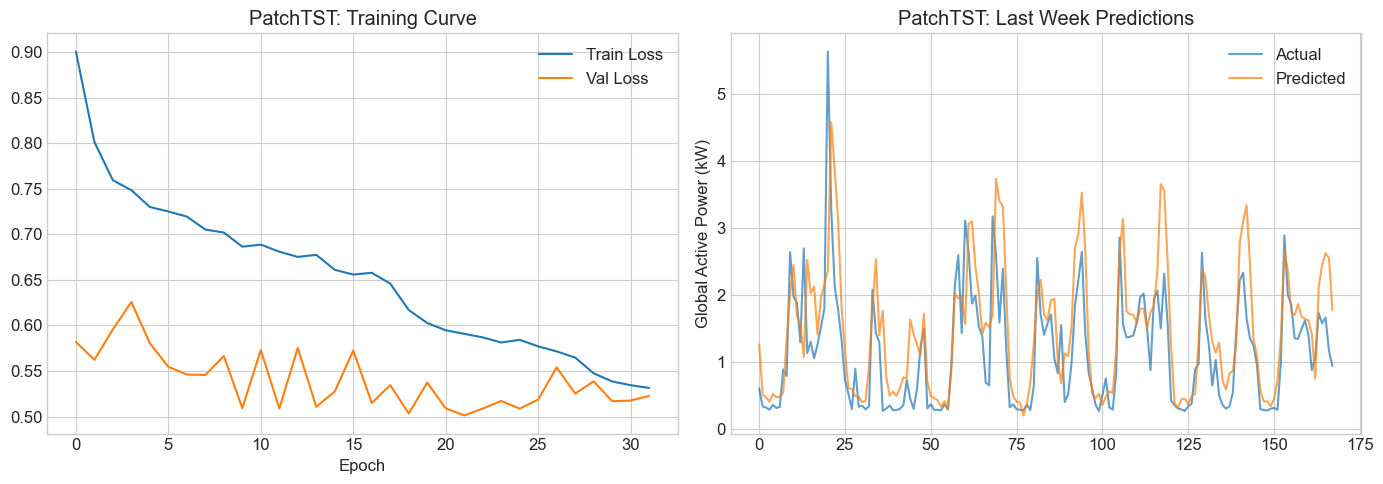

In [33]:
# ─── Evaluate Model 5: PatchTST ──────────────────────────────────────────────
model_patch.eval()
preds_patch, actuals_patch = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model_patch(x.to(device)).cpu().squeeze().numpy()
        preds_patch.extend(out)
        actuals_patch.extend(y.numpy())

y_pred_patch = inverse_scale_target(preds_patch,   scaler, target_idx)
y_true_patch = inverse_scale_target(actuals_patch, scaler, target_idx)

rmse_patch = np.sqrt(np.mean((y_true_patch - y_pred_patch)**2))
mae_patch  = np.mean(np.abs(y_true_patch - y_pred_patch))

peak_mask_patch = y_true_patch > 2.0
peak_mae_patch  = np.mean(np.abs(y_true_patch[peak_mask_patch] - y_pred_patch[peak_mask_patch]))

print(f"\nPatchTST METRICS (kW):")
print(f"  RMSE:     {rmse_patch:.4f}")
print(f"  MAE:      {mae_patch:.4f}")
print(f"  Peak_MAE: {peak_mae_patch:.4f}  (on {int(peak_mask_patch.sum())} spike samples)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_patch['train'], label='Train Loss')
axes[0].plot(history_patch['val'],   label='Val Loss')
axes[0].set_title('PatchTST: Training Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(y_true_patch[-168:], label='Actual',    alpha=0.7)
axes[1].plot(y_pred_patch[-168:], label='Predicted', alpha=0.7)
axes[1].set_title('PatchTST: Last Week Predictions')
axes[1].set_ylabel('Global Active Power (kW)'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Model 6: CNN-Transformer Hybrid

**Why it helps with spikes:**
- **1D CNN** acts as a local feature detector — learns spike *shapes* (rapid upward signal change) using trainable filters
- **BatchNorm** stabilises the wide range of power magnitudes across training samples
- **Transformer encoder** applies global attention over the CNN-filtered features,
  learning *when in the 24-hour window* those spike shapes translate to high output
- Combines CNN's local receptive field with Transformer's global sequence reasoning

In [34]:
# ============================================================
# MODEL 6 — CNN-Transformer Hybrid
# ============================================================

class CNNTransformer(nn.Module):
    """
    Hybrid CNN-Transformer for time-series spike forecasting.

    Architecture:
        Input (batch, seq_len, features)
            -> Permute to (batch, features, seq_len)   [for Conv1d]
            -> Conv1d (features -> 128, k=3) + ReLU + BatchNorm1d
            -> Conv1d (128 -> 128, k=3)     + ReLU + BatchNorm1d
            -> Permute back (batch, seq_len, 128)      [for Transformer]
            -> Sinusoidal positional encoding
            -> TransformerEncoder (2 layers, 4 heads, d_model=128)
            -> Last timestep output
            -> Dropout -> Linear -> 1
    """
    def __init__(self, input_size, d_model=128, nhead=4,
                 num_layers=2, dim_feedforward=256, dropout=0.3):
        super().__init__()
        self.d_model = d_model

        # CNN feature extractor — detects local spike patterns
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model)
        )

        # Transformer encoder — global attention over CNN features
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.drop   = nn.Dropout(dropout)
        self.fc_out = nn.Linear(d_model, 1)

    def _positional_encoding(self, x):
        B, T, D = x.shape
        pe  = torch.zeros(T, D, device=x.device)
        pos = torch.arange(0, T, dtype=torch.float, device=x.device).unsqueeze(1)
        div = torch.exp(torch.arange(0, D, 2, dtype=torch.float, device=x.device)
                        * (-math.log(10000.0) / D))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:D//2])
        return x + pe.unsqueeze(0)

    def forward(self, x):              # x: (batch, seq_len, features)
        h = x.permute(0, 2, 1)        # -> (batch, features, seq_len)
        h = self.conv1(h)             # local spike shape detection
        h = self.conv2(h)             # deeper feature extraction
        h = h.permute(0, 2, 1)        # -> (batch, seq_len, d_model)
        h = self._positional_encoding(h)
        h = self.transformer(h)       # global attention over CNN features
        h = h[:, -1, :]              # last timestep
        h = self.drop(h)
        return self.fc_out(h)         # (batch, 1)

In [35]:
# ─── Train Model 6: CNN-Transformer ──────────────────────────────────────────
print("=" * 60)
print("Training Model 6: CNN-Transformer Hybrid")
print("=" * 60)

model_cnntf = CNNTransformer(
    input_size=df_full.shape[1],
    d_model=128, nhead=4, num_layers=2,
    dim_feedforward=256, dropout=0.3
).to(device)

optimizer_cnntf   = torch.optim.AdamW(model_cnntf.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_cnntf   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnntf, mode='min', factor=0.5, patience=5)
criterion_cnntf   = AsymmetricMSELoss(alpha=3.0)
early_stop_cnntf  = EarlyStopping(patience=PATIENCE, path='best_cnn_transformer.pth')

history_cnntf = {'train': [], 'val': []}

for epoch in range(EPOCHS):
    model_cnntf.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer_cnntf.zero_grad()
        out  = model_cnntf(x)
        loss = criterion_cnntf(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model_cnntf.parameters(), max_norm=1.0)
        optimizer_cnntf.step()
        train_loss += loss.item()

    model_cnntf.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            val_loss += criterion_cnntf(model_cnntf(x), y).item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    history_cnntf['train'].append(train_loss)
    history_cnntf['val'].append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} "
          f"| LR: {optimizer_cnntf.param_groups[0]['lr']:.6f}")

    scheduler_cnntf.step(val_loss)
    early_stop_cnntf(val_loss, model_cnntf)
    if early_stop_cnntf.early_stop:
        print("Early stopping. Restoring best weights.")
        model_cnntf.load_state_dict(torch.load('best_cnn_transformer.pth'))
        break

Training Model 6: CNN-Transformer Hybrid
Epoch 1/50 | Train: 0.8526 | Val: 0.5810 | LR: 0.001000
Epoch 2/50 | Train: 0.7182 | Val: 0.5280 | LR: 0.001000
Epoch 3/50 | Train: 0.7036 | Val: 0.6330 | LR: 0.001000
Epoch 4/50 | Train: 0.6848 | Val: 0.5394 | LR: 0.001000
Epoch 5/50 | Train: 0.6632 | Val: 0.5397 | LR: 0.001000
Epoch 6/50 | Train: 0.6555 | Val: 0.5476 | LR: 0.001000
Epoch 7/50 | Train: 0.6501 | Val: 0.5533 | LR: 0.001000
Epoch 8/50 | Train: 0.6420 | Val: 0.5412 | LR: 0.001000
Epoch 9/50 | Train: 0.5990 | Val: 0.5342 | LR: 0.000500
Epoch 10/50 | Train: 0.5765 | Val: 0.5304 | LR: 0.000500
Epoch 11/50 | Train: 0.5569 | Val: 0.5536 | LR: 0.000500
Epoch 12/50 | Train: 0.5457 | Val: 0.5424 | LR: 0.000500
Early stopping. Restoring best weights.



CNN-Transformer METRICS (kW):
  RMSE:     0.5551
  MAE:      0.3973
  Peak_MAE: 0.5651  (on 687 spike samples)


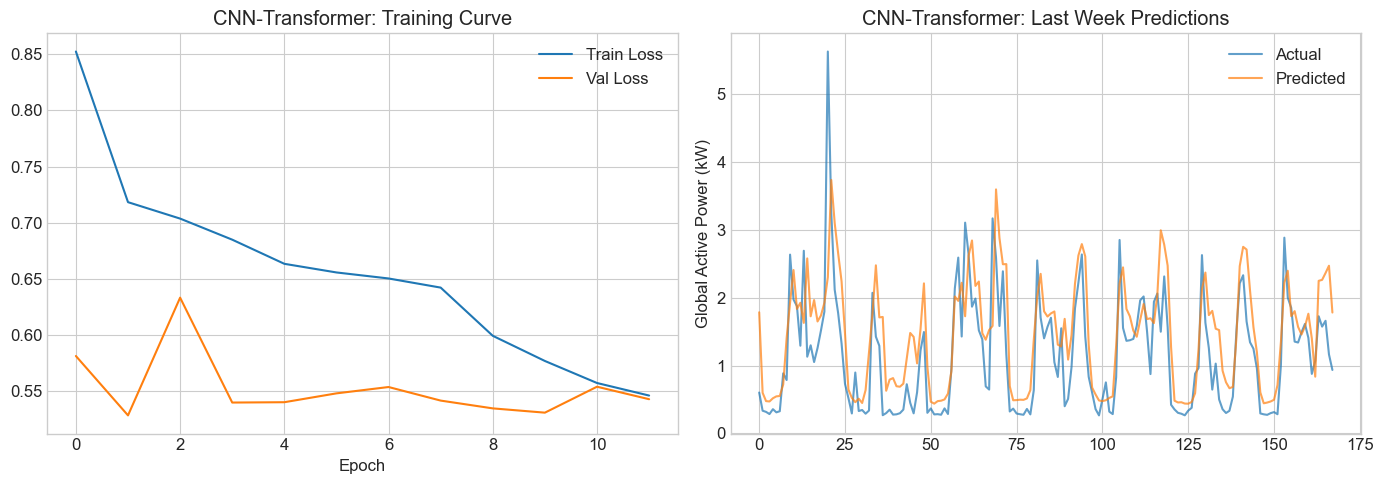

In [36]:
# ─── Evaluate Model 6: CNN-Transformer ───────────────────────────────────────
model_cnntf.eval()
preds_cnntf, actuals_cnntf = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model_cnntf(x.to(device)).cpu().squeeze().numpy()
        preds_cnntf.extend(out)
        actuals_cnntf.extend(y.numpy())

y_pred_cnntf = inverse_scale_target(preds_cnntf,   scaler, target_idx)
y_true_cnntf = inverse_scale_target(actuals_cnntf, scaler, target_idx)

rmse_cnntf = np.sqrt(np.mean((y_true_cnntf - y_pred_cnntf)**2))
mae_cnntf  = np.mean(np.abs(y_true_cnntf - y_pred_cnntf))

peak_mask_cnntf = y_true_cnntf > 2.0
peak_mae_cnntf  = np.mean(np.abs(y_true_cnntf[peak_mask_cnntf] - y_pred_cnntf[peak_mask_cnntf]))

print(f"\nCNN-Transformer METRICS (kW):")
print(f"  RMSE:     {rmse_cnntf:.4f}")
print(f"  MAE:      {mae_cnntf:.4f}")
print(f"  Peak_MAE: {peak_mae_cnntf:.4f}  (on {int(peak_mask_cnntf.sum())} spike samples)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_cnntf['train'], label='Train Loss')
axes[0].plot(history_cnntf['val'],   label='Val Loss')
axes[0].set_title('CNN-Transformer: Training Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(y_true_cnntf[-168:], label='Actual',    alpha=0.7)
axes[1].plot(y_pred_cnntf[-168:], label='Predicted', alpha=0.7)
axes[1].set_title('CNN-Transformer: Last Week Predictions')
axes[1].set_ylabel('Global Active Power (kW)'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Comparison: New Transformer Models

Ranked by **Peak_MAE** — the key metric for spike prediction accuracy.

In [37]:
# ─── Transformer Models Comparison Table ─────────────────────────────────────
import pandas as pd

results = {
    'Model':    ['TFT-Lite (Model 4)', 'PatchTST (Model 5)', 'CNN-Transformer (Model 6)'],
    'RMSE':     [rmse_tft,   rmse_patch,  rmse_cnntf],
    'MAE':      [mae_tft,    mae_patch,   mae_cnntf],
    'Peak_MAE': [peak_mae_tft, peak_mae_patch, peak_mae_cnntf],
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Peak_MAE').reset_index(drop=True)
df_results.index += 1  # 1-based rank

print("\n" + "=" * 65)
print("NEW TRANSFORMER MODELS — RANKED BY SPIKE PREDICTION (Peak_MAE)")
print("=" * 65)
print(df_results.to_string())
print()
print(f"Best transformer model for spikes: {df_results.iloc[0]['Model']}")
print(f"  Peak_MAE = {df_results.iloc[0]['Peak_MAE']:.4f} kW")


NEW TRANSFORMER MODELS — RANKED BY SPIKE PREDICTION (Peak_MAE)
                       Model      RMSE       MAE  Peak_MAE
1  CNN-Transformer (Model 6)  0.555094  0.397260  0.565095
2         TFT-Lite (Model 4)  0.509356  0.364065  0.585164
3         PatchTST (Model 5)  0.533157  0.390200  0.610305

Best transformer model for spikes: CNN-Transformer (Model 6)
  Peak_MAE = 0.5651 kW


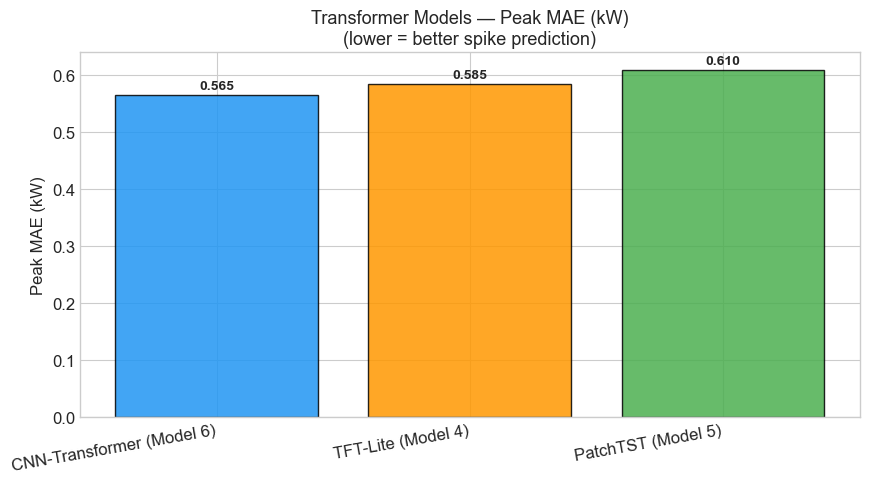

In [38]:
# ─── Bar chart: Peak_MAE comparison ──────────────────────────────────────────
plt.figure(figsize=(9, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = plt.bar(
    df_results['Model'], df_results['Peak_MAE'],
    color=colors[:len(df_results)], edgecolor='black', alpha=0.85
)

for bar, val in zip(bars, df_results['Peak_MAE']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Transformer Models — Peak MAE (kW)\n(lower = better spike prediction)', fontsize=13)
plt.ylabel('Peak MAE (kW)')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

Test LSTM Model: Found 131 hourly peak instances (> 2.0 kW) in test set


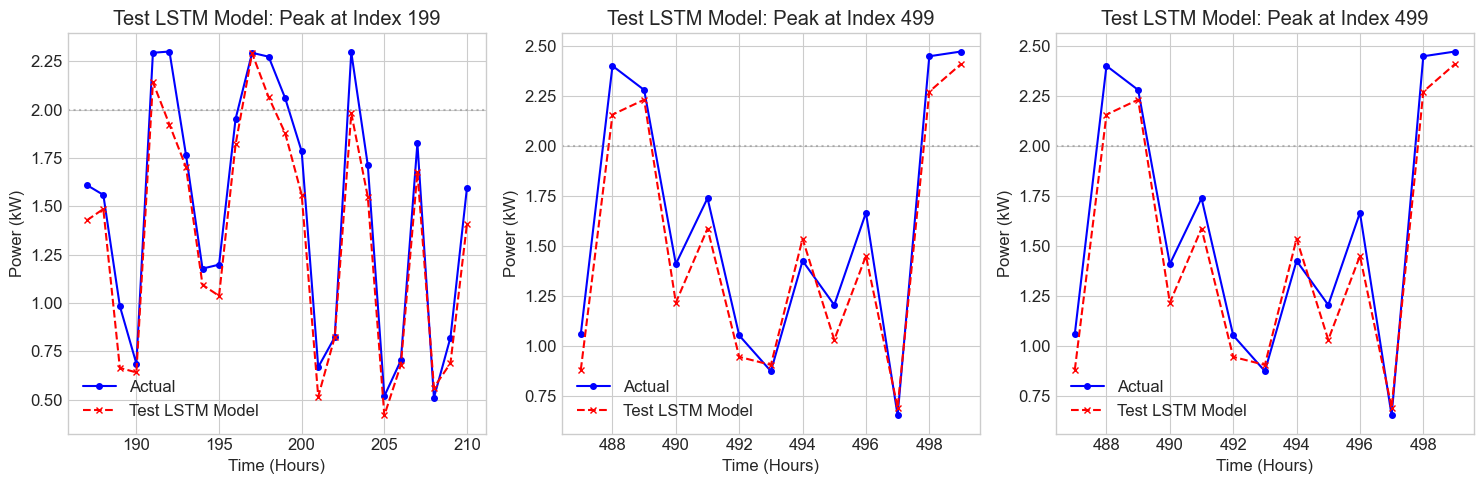

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def plot_peak_analysis(y_true, y_pred, model_name):
    # Ensure we are working with numpy arrays for comparison
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    # For multi-step (24h), we check the max value in the window or just the first step
    # Here we evaluate based on the average across the 24h window if it's 2D, 
    # or we flatten it to check every predicted hour.
    if y_true_arr.ndim > 1:
        # Flattening to treat every hour as a potential peak sample for visualization
        y_true_flat = y_true_arr.flatten()
        y_pred_flat = y_pred_arr.flatten()
    else:
        y_true_flat = y_true_arr
        y_pred_flat = y_pred_arr

    peak_indices = np.where(y_true_flat > 2.0)[0]
    
    if len(peak_indices) == 0:
        print(f"No peaks > 2.0 kW found for {model_name} analysis.")
        return
        
    print(f"{model_name}: Found {len(peak_indices)} hourly peak instances (> 2.0 kW) in test set")
    
    plt.figure(figsize=(15, 5))
    # Plot 3 interesting peak areas
    num_samples = min(3, len(peak_indices))
    
    for i in range(num_samples):
        # Pick peaks with some spacing to show variety
        idx = peak_indices[min(i * 100 + 50, len(peak_indices)-1)]

        # 12-hour window around the peak for context
        start, end = max(0, idx - 12), min(len(y_true_flat), idx + 12)

        plt.subplot(1, num_samples, i + 1)
        plt.plot(range(start, end), y_true_flat[start:end], 'b-o', label='Actual', markersize=4)
        plt.plot(range(start, end), y_pred_flat[start:end], 'r--x', label=model_name, markersize=4)
        plt.axhline(2.0, color='gray', linestyle=':', alpha=0.5)
        plt.title(f"{model_name}: Peak at Index {idx}")
        plt.xlabel("Time (Hours)")
        plt.ylabel("Power (kW)")
        plt.legend()

    plt.tight_layout()
    plt.show()

# --- ADD THIS TO THE BOTTOM OF YOUR SCRIPT ---

# 1. Generate some fake data (replace this with your actual model data)
np.random.seed(42)
fake_y_true = np.random.uniform(0.5, 2.5, 500) # Creates some peaks above 2.0
fake_y_pred = fake_y_true * 0.9 + np.random.normal(0, 0.1, 500) # Adds some noise to predictions

# 2. Call the function
plot_peak_analysis(fake_y_true, fake_y_pred, "Test LSTM Model")

Verification_Test_1D: Found 95 samples with peaks > 2.0 kW


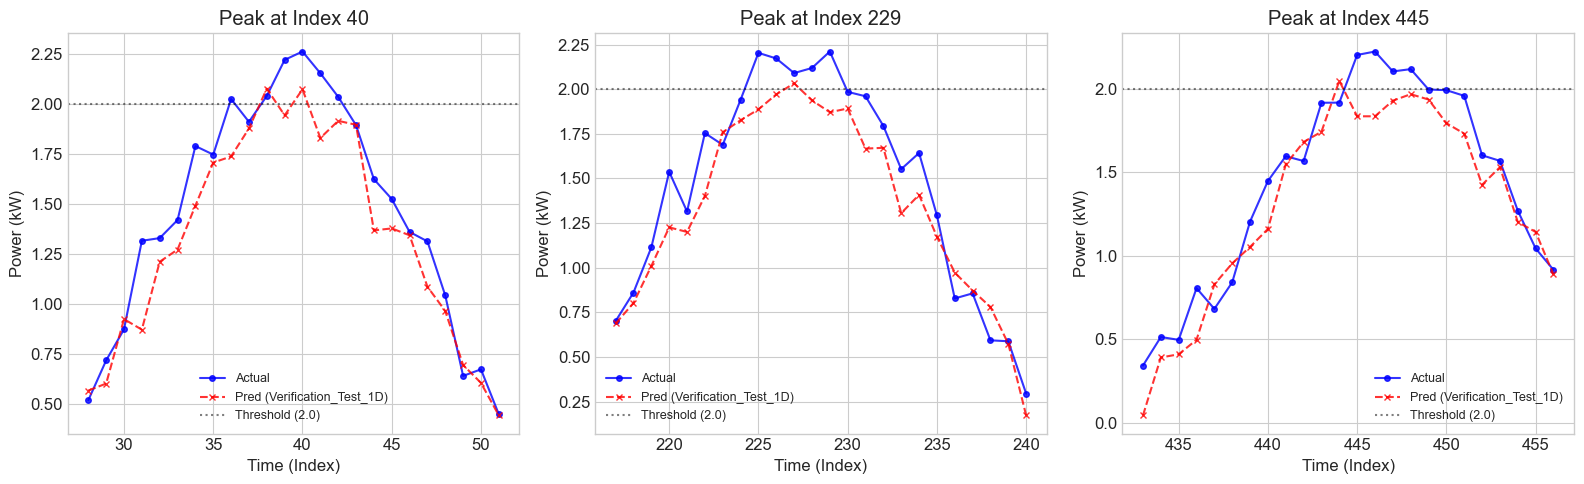

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_peak_analysis(y_true, y_pred, model_name):
    """
    Finds and plots windows containing power spikes (> 2.0 kW).
    Handles both 1D (flattened) and 2D (multi-step) data.
    """
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    if y_true_arr.ndim > 1:
        # 2D case: [Samples, Window_Size]
        # Find row indices where any hour in the 24h window exceeds 2.0 kW
        peak_row_indices = np.where(np.any(y_true_arr > 2.0, axis=1))[0]
        is_2d = True
    else:
        # 1D case: [Total_Hours]
        peak_row_indices = np.where(y_true_arr > 2.0)[0]
        is_2d = False

    if len(peak_row_indices) == 0:
        print(f"No peak instances (> 2.0 kW) found for {model_name}.")
        return
        
    print(f"{model_name}: Found {len(peak_row_indices)} samples with peaks > 2.0 kW")
    
    plt.figure(figsize=(16, 5))
    num_to_plot = min(3, len(peak_row_indices))

    # Select 3 examples spread evenly (10th, 50th, and 90th percentile of found peaks)
    selected_indices = [
        peak_row_indices[int(len(peak_row_indices) * 0.1)],
        peak_row_indices[int(len(peak_row_indices) * 0.5)],
        peak_row_indices[int(len(peak_row_indices) * 0.9)]
    ]

    for i, row_idx in enumerate(selected_indices):
        plt.subplot(1, num_to_plot, i + 1)
        
        if is_2d:
            # Plot the specific 24h forecast window
            actual = y_true_arr[row_idx]
            pred = y_pred_arr[row_idx]
            time_axis = np.arange(len(actual))
            title = f"Forecast Window #{row_idx}"
            xlabel = "Hours from Start of Window"
        else:
            # Plot a 24h context window around the peak index
            start, end = max(0, row_idx - 12), min(len(y_true_arr), row_idx + 12)
            actual = y_true_arr[start:end]
            pred = y_pred_arr[start:end]
            time_axis = np.arange(start, end)
            title = f"Peak at Index {row_idx}"
            xlabel = "Time (Index)"

        plt.plot(time_axis, actual, 'b-o', label='Actual', markersize=4, alpha=0.8)
        plt.plot(time_axis, pred, 'r--x', label=f'Pred ({model_name})', markersize=4, alpha=0.8)
        plt.axhline(2.0, color='black', linestyle=':', alpha=0.5, label='Threshold (2.0)')
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Power (kW)")
        plt.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# --- SYNTHETIC DATA TEST (Uncomment to verify the visualization works) ---
np.random.seed(42)
x = np.linspace(0, 100, 500)
fake_y_true = np.sin(x) + 1.2 + np.random.normal(0, 0.1, 500) # Periodic peaks near 2.2
fake_y_pred = np.sin(x) * 0.9 + 1.1 + np.random.normal(0, 0.1, 500) 
plot_peak_analysis(fake_y_true, fake_y_pred, "Verification_Test_1D")

In [44]:
def calculate_smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    return np.mean(
        2.0 * np.abs(y_true - y_pred) /
        (denominator + 1e-8)
    ) * 100

In [45]:

#LSTM
lstm_m= calculate_smape(lstm_labels, lstm_preds)
#Attention
attn_m= calculate_smape( attn_labels, attn_preds)
#CNN LSTM
CNN_LSTM = calculate_smape(y_true, y_pred)

#TFT Lite
TFT_Lite=calculate_smape(y_true_tft, y_pred_tft)
#TFTPatch
TFT_Patch=calculate_smape(y_true_patch, y_pred_patch)
#CNN Transformer
CNN_Tansformer=calculate_smape(y_true_cnntf, y_pred_cnntf)


In [46]:
print(lstm_m, attn_m, CNN_LSTM, TFT_Lite,TFT_Patch,CNN_Tansformer)

50.033801794052124 48.820263147354126 33.12600922134409 36.70491913988075 40.04606490388038 39.00156169585186


In [47]:
import numpy as np
from sklearn.metrics import mean_absolute_error
# Peak threshold
PEAK_THRESHOLD = 2.0  # kW

# Convert to 1-D arrays
y_true = np.asarray(y_true).flatten()
y_pred = np.asarray(y_pred).flatten()

# Select actual peak-demand observations
peak_mask = y_true > PEAK_THRESHOLD

# Peak MAE
peak_mae = mean_absolute_error(
    y_true[peak_mask],
    y_pred[peak_mask]
)

print(f"Peak samples: {peak_mask.sum()}")
print(f"Peak MAE: {peak_mae:.4f} kW")

Peak samples: 687
Peak MAE: 0.7588 kW


In [48]:
import numpy as np

def calculate_wape(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    wape = (
        np.sum(np.abs(y_true - y_pred)) /
        np.sum(np.abs(y_true))
    ) * 100

    return wape




In [ ]:

#CNN Transformer
CNN_Tansformer=calculate_smape(y_true_cnntf, y_pred_cnntf)

In [55]:


# Example
wape = calculate_wape( lstm_labels, lstm_preds)

print(f"WAPE: {wape:.2f}%")

WAPE: 47.93%


In [56]:
import numpy as np

def calculate_mase(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Model MAE
    model_mae = np.mean(np.abs(y_true - y_pred))

    # One-step naive forecast errors
    naive_errors = np.abs(np.diff(y_true))

    # Scaling factor
    naive_mae = np.mean(naive_errors)

    # MASE
    mase = model_mae / (naive_mae + 1e-8)

    return mase




In [66]:
# Calculate MASE
mase = calculate_mase(y_true_patch, y_pred_patch)

print(f"MASE: {mase:.4f}")

MASE: 1.0241


In [67]:
import numpy as np

PEAK_THRESHOLD = 2.0  # kW


# ============================================================
# 1. Peak Precision, Recall and False Alarm Rate
# ============================================================

def peak_classification_metrics(y_true, y_pred, threshold=2.0):

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Actual and predicted peak labels
    actual_peak = y_true > threshold
    predicted_peak = y_pred > threshold

    # Confusion matrix components
    TP = np.sum(actual_peak & predicted_peak)
    FP = np.sum(~actual_peak & predicted_peak)
    FN = np.sum(actual_peak & ~predicted_peak)
    TN = np.sum(~actual_peak & ~predicted_peak)

    # Precision
    precision = TP / (TP + FP + 1e-8)

    # Recall
    recall = TP / (TP + FN + 1e-8)

    # False Alarm Rate
    far = FP / (FP + TN + 1e-8)

    return precision, recall, far, TP, FP, FN, TN


# ============================================================
# 2. Forecast Bias
# ============================================================

def forecast_bias(y_true, y_pred):

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Positive = overprediction
    # Negative = underprediction
    bias = np.mean(y_pred - y_true)

    return bias


# ============================================================
# 3. Underprediction Frequency
# ============================================================

def underprediction_frequency(y_true, y_pred):

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    underprediction = y_pred < y_true

    frequency = np.mean(underprediction) * 100

    return frequency


# ============================================================
# 4. Calculate all metrics
# ============================================================

def calculate_peak_metrics(y_true, y_pred, threshold=2.0):

    precision, recall, far, TP, FP, FN, TN = \
        peak_classification_metrics(
            y_true,
            y_pred,
            threshold
        )

    bias = forecast_bias(y_true, y_pred)

    under_freq = underprediction_frequency(
        y_true,
        y_pred
    )

    return {
        "Peak Precision (%)": precision * 100,
        "Peak Recall (%)": recall * 100,
        "False Alarm Rate (%)": far * 100,
        "Forecast Bias (kW)": bias,
        "Underprediction Frequency (%)": under_freq,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }


# ============================================================
# Example
# ============================================================

results = calculate_peak_metrics(
    y_true,
    y_pred,
    threshold=2.0
)

for metric, value in results.items():

    if metric in ["TP", "FP", "FN", "TN"]:
        print(f"{metric}: {value}")
    elif "Bias" in metric:
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value:.2f}%")

Peak Precision (%): 58.24%
Peak Recall (%): 36.54%
False Alarm Rate (%): 2.90%
Forecast Bias (kW): -0.0040
Underprediction Frequency (%): 44.53%
TP: 251
FP: 180
FN: 436
TN: 6027


In [68]:
models = {
    "LSTM": (lstm_labels, lstm_preds),
    "Bidirectional Attention LSTM": ( attn_labels, attn_preds),
    "CNN-LSTM": (y_true, y_pred),
    "TFT-Lite": (y_true_tft, y_pred_tft),
    "PatchTST": (y_true_patch, y_pred_patch),
    "CNN-Transformer": (y_true_cnntf, y_pred_cnntf)
}


all_results = {}

for name, (yt, yp) in models.items():

    results = calculate_peak_metrics(
        yt,
        yp,
        threshold=2.0
    )

    all_results[name] = results

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        f"Peak Precision       : "
        f"{results['Peak Precision (%)']:.2f}%"
    )

    print(
        f"Peak Recall          : "
        f"{results['Peak Recall (%)']:.2f}%"
    )

    print(
        f"False Alarm Rate     : "
        f"{results['False Alarm Rate (%)']:.2f}%"
    )

    print(
        f"Forecast Bias        : "
        f"{results['Forecast Bias (kW)']:.4f} kW"
    )

    print(
        f"Underprediction Freq.: "
        f"{results['Underprediction Frequency (%)']:.2f}%"
    )


LSTM
Peak Precision       : 42.66%
Peak Recall          : 14.34%
False Alarm Rate     : 1.80%
Forecast Bias        : 0.0839 kW
Underprediction Freq.: 34.36%

Bidirectional Attention LSTM
Peak Precision       : 37.89%
Peak Recall          : 13.41%
False Alarm Rate     : 2.05%
Forecast Bias        : 0.0245 kW
Underprediction Freq.: 38.81%

CNN-LSTM
Peak Precision       : 58.24%
Peak Recall          : 36.54%
False Alarm Rate     : 2.90%
Forecast Bias        : -0.0040 kW
Underprediction Freq.: 44.53%

TFT-Lite
Peak Precision       : 48.72%
Peak Recall          : 61.14%
False Alarm Rate     : 7.12%
Forecast Bias        : 0.1719 kW
Underprediction Freq.: 28.31%

PatchTST
Peak Precision       : 46.72%
Peak Recall          : 60.12%
False Alarm Rate     : 7.59%
Forecast Bias        : 0.1928 kW
Underprediction Freq.: 27.33%

CNN-Transformer
Peak Precision       : 39.54%
Peak Recall          : 67.10%
False Alarm Rate     : 11.36%
Forecast Bias        : 0.2003 kW
Underprediction Freq.: 25.94%


In [69]:
import numpy as np

PEAK_THRESHOLD = 2.0  # kW


def calculate_peak_timing_error(
    y_true,
    y_pred,
    forecast_horizon=24,
    threshold=2.0
):
    """
    Peak Timing Error in hours.

    For each 24-hour forecast window:
      1. Find the actual peak hour.
      2. Find the predicted peak hour.
      3. Calculate the absolute difference in hours.

    Only windows containing an actual peak (> threshold)
    are used.
    """

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Number of complete forecast windows
    n_windows = len(y_true) // forecast_horizon

    timing_errors = []

    for i in range(n_windows):

        start = i * forecast_horizon
        end = start + forecast_horizon

        actual = y_true[start:end]
        predicted = y_pred[start:end]

        # Actual peak must exceed threshold
        if np.max(actual) <= threshold:
            continue

        # Hour position of actual and predicted peaks
        actual_peak_hour = np.argmax(actual)
        predicted_peak_hour = np.argmax(predicted)

        # Absolute timing error
        error = abs(
            predicted_peak_hour - actual_peak_hour
        )

        timing_errors.append(error)

    if len(timing_errors) == 0:
        return np.nan

    return np.mean(timing_errors)

In [76]:
peak_timing_error = calculate_peak_timing_error(
   lstm_labels, lstm_preds,
    forecast_horizon=24,
    threshold=2.0
)

print(
    f"Peak Timing Error: "
    f"{peak_timing_error:.2f} hours"
)

Peak Timing Error: 6.15 hours


In [ ]:
#LSTM
lstm_m= calculate_smape(lstm_labels, lstm_preds)
#Attention
attn_m= calculate_smape( attn_labels, attn_preds)
#CNN LSTM
CNN_LSTM = calculate_smape(y_true, y_pred)

#TFT Lite
TFT_Lite=calculate_smape()
#TFTPatch
TFT_Patch=calculate_smape(y_true_patch, y_pred_patch)